# Домашнее задание: Занятие 33

**Тема: Батчи и эпохи -- обработка больших данных**

В этом задании вы закрепите понимание батчей, эпох и итераций. Каждое задание ссылается на конкретный слайд из презентации -- если забыли, вернитесь к нему.

---

## Часть 1: Теория (40 баллов)

Отвечайте своими словами, не копируйте.

### Вопрос 1 (8 баллов)

*(Слайды 5-6)*

а) Почему нельзя подать весь датасет в модель за один раз? Приведите конкретный пример с числами (размер данных vs память GPU).

б) Дайте определение трём понятиям: **Batch**, **Epoch**, **Iteration**. Для каждого приведите аналогию из жизни.

**Ваш ответ:**
1) Потому что память видеокарты ограничена, весь датасет просто туда не влезет. Например, датасет весит 50 ГБ, а видеопамять на вашей карте всего 8 ГБ, попытка загрузить всё сразу вызовет ошибку Out of Memory
2)
- Batch: Порция данных, которую модель обрабатывает за один раз
- Epoch: Один полный проход по всему датасету (все батчи пройдены один раз)
- Iteration: Один шаг обновления весов модели (обработка одного батча)


### Вопрос 2 (8 баллов)

*(Слайды 9-10)*

Датасет содержит 60 000 образцов. Batch size = 128. Количество эпох = 15.

Посчитайте:
- Сколько итераций за одну эпоху?
- Сколько образцов останется в последнем (неполном) батче?
- Сколько итераций за все обучение?
- Если каждая итерация занимает 0.05 секунд, сколько МИНУТ займёт обучение?

**Ваш ответ:**
- Итераций за эпоху: 60000/128 = 468.75 (469 итераций)
- Остаток в последнем батче: 60000/128 = остаток 96 образцов
- Всего итераций: 469*15 = 7035 итераций
- Время обучения: 351.75/60 = 5.86 минут


### Вопрос 3 (8 баллов)

*(Слайд 13)*

Сравните маленький batch size (8) и большой (512). Для каждого назовите:
- Два преимущества
- Два недостатка

Какой batch size вы бы выбрали для обучения модели на GPU с 8 GB памяти на датасете из 100 000 картинок 128x128x3? Объясните выбор.

**Ваш ответ:**
- Маленький батч:

Преимущества:
1. Меньше памяти
2. Лучше обобщает, шум помогает выйти из локальных минимумов

Недостатки:
1. Долгое обучение
2. Скачущий, нестабильный график лосса

- Большой батч:

Преимущества:
1. Быстрее учится, лучше использует параллелизм GPU
2. Градиент стабильнее

Недостатки:
1. Нужно очень много памяти
2. Может застрять в плохих решениях

### Вопрос 4 (8 баллов)

*(Слайды 15, 18)*

а) Что такое Linear Scaling Rule? Вы обучали модель с batch=32 и lr=0.001. Хотите перейти на batch=256. Какой lr поставить и почему?

б) В чём разница между `model.train()` и `model.eval()`? Какие слои ведут себя по-разному и как именно?

**Ваш ответ:**
1) Linear Scaling Rule это если мы увеличиваем батч в N раз, нужно в столько же раз увеличить скорость обучения (Learning Rate). Решение: был батч 32, стал 256, значит ставим lr = 0.008 (0.001*8). Это нужно, чтобы модель делала более уверенные шаги, так как градиент от большого батча точнее
2) Разница между model.train() и model.eval()
- train(): Режим обучения. Включает слои Dropout (случайно отключает нейроны) и BatchNorm (считает статистику по текущему батчу).
- eval(): Режим оценки. Отключает Dropout и использует накопленную статистику в BatchNorm, чтобы предсказания были стабильными.


### Вопрос 5 (8 баллов)

*(Слайды 17, 19-20)*

Найдите 4 ошибки в коде ниже и исправьте их:

```python
for epoch in range(10):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()            
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    
    model.eval()                       
    correct = 0
    total = 0
    with torch.no_grad():               
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            preds = output.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
```

Перепишите код правильно.

**Ваш ответ:**
Ошибки:
1. X_batch, y_batch не перенесены на GPU
2. Отсутствует optimizer.zero_grad() перед расчетом градиентов
3. Не включен режим model.eval() перед тестом
4. Тестовый цикл не обернут в with torch.no_grad()


---

## Часть 2: Код (60 баллов)

### Подготовка

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
# Загружаем Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_data = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

print(f'Train: {len(train_data)}')
print(f'Test:  {len(test_data)}')

class_names = ['Футболка', 'Брюки', 'Свитер', 'Платье', 'Пальто',
               'Сандалии', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботинки']

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 267kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.7MB/s]


Train: 60000
Test:  10000


### Задание 1: Создайте DataLoader (10 баллов)

*(Слайд 11)*

Создайте DataLoader для train и test данных.
- batch_size = 64
- shuffle = True для train, False для test
- drop_last = True для train

Выведите: количество батчей, размер одного батча.

In [3]:
BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f'Батчей в train: {len(train_loader)}')
print(f'Батчей в test:  {len(test_loader)}')

for images, labels in train_loader:
    print(f'\nImages shape: {images.shape}')
    print(f'Labels shape: {labels.shape}')
    break

Батчей в train: 937
Батчей в test:  157

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


### Задание 2: Постройте модель (10 баллов)

*(Слайды 17-18)*

Создайте CNN для Fashion-MNIST:
- Conv2d(1, 16, 3, padding=1) + ReLU + MaxPool2d(2)
- Conv2d(16, 32, 3, padding=1) + ReLU + MaxPool2d(2)
- Flatten + Dropout(0.25) + Linear(32*7*7, 128) + ReLU + Linear(128, 10)

In [4]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = FashionCNN().to(device)
print(model)
print(f'\nПараметров: {sum(p.numel() for p in model.parameters()):,}')

FashionCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=1568, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Параметров: 206,922


### Задание 3: Напишите Training Loop (15 баллов)

*(Слайды 17, 19)*

Напишите полный цикл обучения на 10 эпох:
- CrossEntropyLoss, Adam с lr=0.001
- Сохраняйте train_loss и test_accuracy на каждой эпохе
- Не забудьте: model.train(), model.eval(), .to(device), torch.no_grad()
- Выводите прогресс каждые 2 эпохи

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 10
train_losses = []
test_accs = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    test_accs.append(correct / total)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}  Loss: {train_losses[-1]:.4f}  Acc: {test_accs[-1]:.2%}')

Epoch 2/10  Loss: 0.3208  Acc: 88.81%
Epoch 4/10  Loss: 0.2462  Acc: 88.38%
Epoch 6/10  Loss: 0.2105  Acc: 90.87%
Epoch 8/10  Loss: 0.1822  Acc: 91.86%
Epoch 10/10  Loss: 0.1578  Acc: 91.84%


### Задание 4: Графики обучения (5 баллов)

Постройте два графика рядом: Train Loss и Test Accuracy по эпохам.

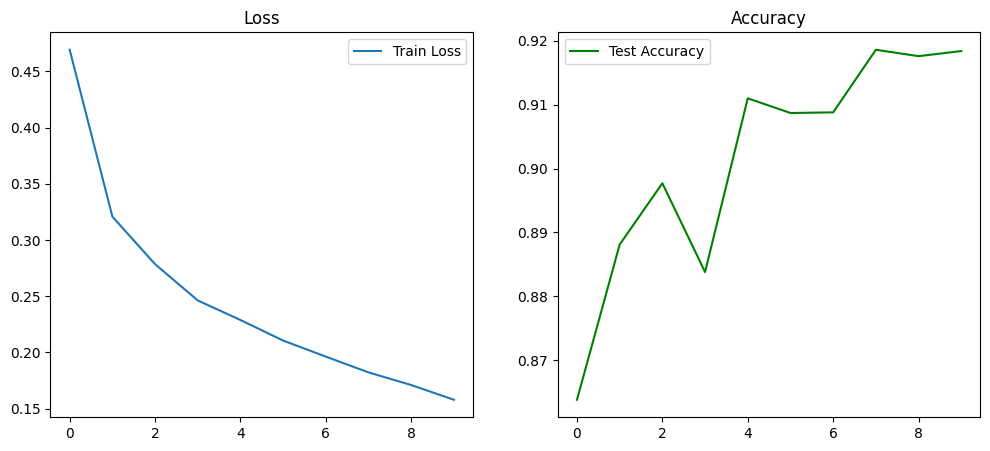

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accs, label='Test Accuracy', color='green')
plt.title('Accuracy')
plt.legend()
plt.show()

### Задание 5: Эксперимент с Batch Size (15 баллов)

*(Слайды 13-14)*

Обучите ту же модель FashionCNN с тремя разными batch size: **16**, **64**, **256**. Для каждого:
- Обучите на 10 эпох (lr=0.001 для всех)
- Засеките время обучения
- Запишите финальную accuracy

Постройте:
1. График Test Accuracy по эпохам (все три на одном графике)
2. Барчарт времени обучения

Напишите вывод: какой batch size лучше и почему?

In [7]:
def train_model(batch_size, lr=0.001, num_epochs=10):
    t_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    v_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    m = FashionCNN().to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    accs = []
    start_time = time.time()

    for epoch in range(num_epochs):
        m.train()
        for X, y in t_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); crit(m(X), y).backward(); opt.step()

        m.eval()
        corr, tot = 0, 0
        with torch.no_grad():
            for X, y in v_loader:
                X, y = X.to(device), y.to(device)
                corr += (m(X).argmax(1) == y).sum().item()
                tot += y.size(0)
        accs.append(corr / tot)

    end_time = time.time() - start_time
    return accs, end_time, m

results = {}
for bs in [16, 64, 256]:
    print(f'Training with batch_size={bs}...')
    accs, duration, last_model = train_model(bs)
    results[bs] = {'accs': accs, 'time': duration, 'model': last_model}


Training with batch_size=16...
Training with batch_size=64...
Training with batch_size=256...


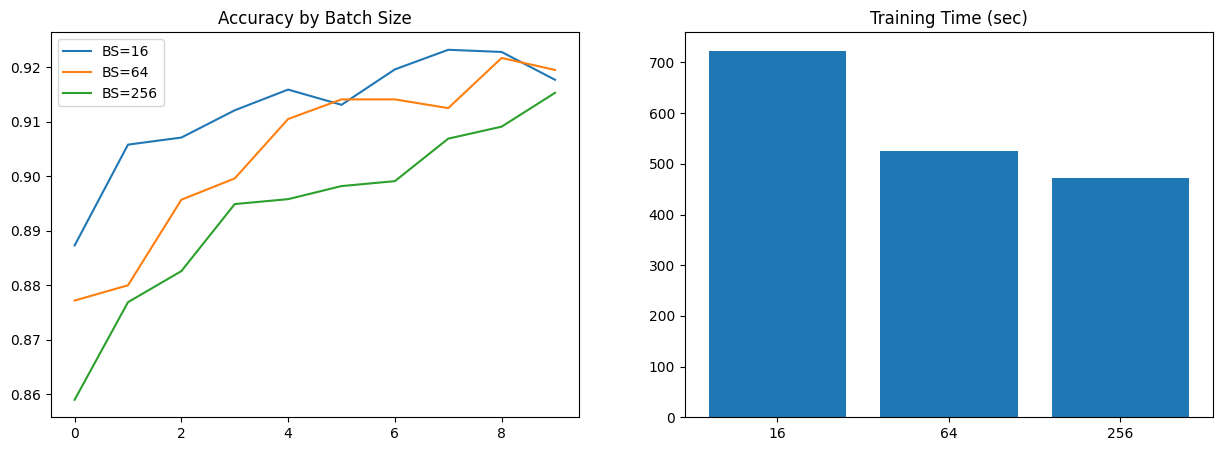

In [8]:
# Графики сравнения
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for bs, res in results.items():
    plt.plot(res['accs'], label=f'BS={bs}')
plt.title('Accuracy by Batch Size')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar([str(bs) for bs in results.keys()], [res['time'] for res in results.values()])
plt.title('Training Time (sec)')
plt.show()


**Ваш вывод:**
batch_size 64 или 256 лучше, так как они быстрее обучаются и дают более стабильный график точности. Маленький батч 16 обучается дольше всего


### Задание 6: Визуализация предсказаний (5 баллов)

Возьмите лучшую модель из Задания 5. Покажите 16 случайных картинок из тестового набора с предсказаниями модели. Правильные -- зелёным, неправильные -- красным.

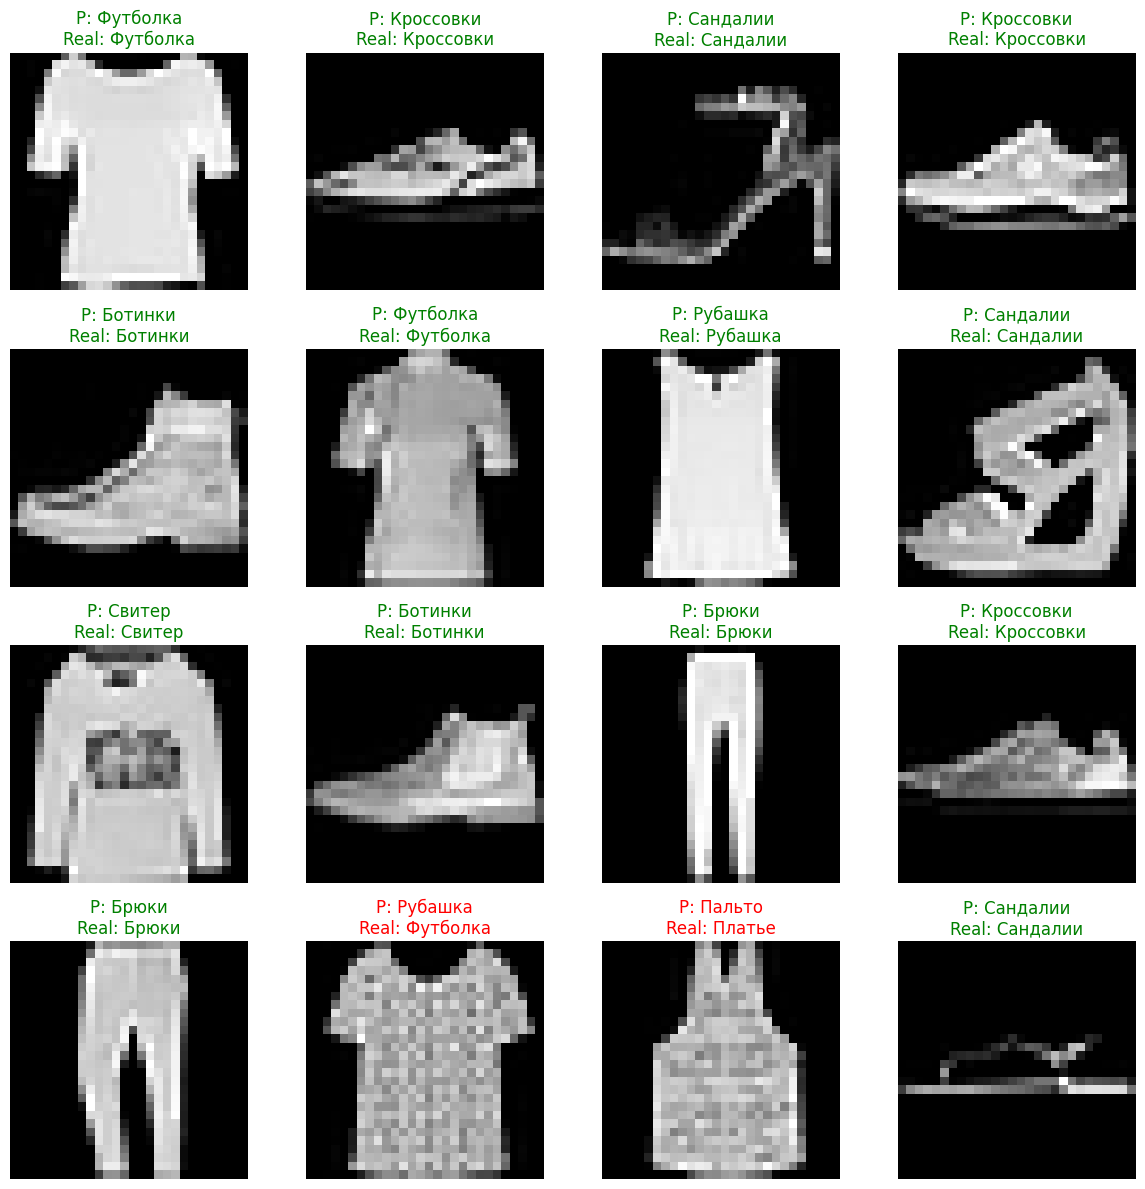

In [9]:
best_model = results[64]['model']
best_model.eval()

images, labels = next(iter(DataLoader(test_data, batch_size=16, shuffle=True)))
with torch.no_grad():
    outputs = best_model(images.to(device))
    preds = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    plt.title(f"P: {class_names[preds[i]]}\nReal: {class_names[labels[i]]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

---

## Часть 3: Бонус (20 баллов)

### Бонус 1: Linear Scaling Rule на Fashion-MNIST (10 баллов)

Обучите модель с тремя конфигурациями:
1. batch=32, lr=0.001 (baseline)
2. batch=128, lr=0.001 (без коррекции)
3. batch=128, lr=0.004 (с linear scaling: batch x4 -> lr x4)

Постройте график accuracy и напишите вывод: помогает ли Linear Scaling Rule?

In [ ]:
# Ваш код здесь



**Ваш вывод:**



### Бонус 2: Переобучение (10 баллов)

Обучите модель на **маленькой части** Fashion-MNIST (используйте только первые 500 образцов из train). Обучите на 50 эпох.

Постройте на одном графике Train Loss и Test Loss по эпохам. Видите ли вы переобучение? Когда оно начинается? Какой batch size и сколько эпох были бы оптимальны?

In [ ]:
# Ваш код здесь



**Ваш вывод:**

